# FSA Dimensionality Scaling: De Jong 1 ($\mathbb{R}^n$)

How does Fast Simulated Annealing perform as the **dimensionality** of a continuous objective function grows?  
This notebook benchmarks FSA on the **De Jong 1** (sphere) function

$$f(\mathbf{x}) = \sum_{i=1}^{n} x_i^2, \quad x_i \in [-5.12,\, 5.12]$$

across dimensions $n \in \{2, 5, 10\}$, comparing three parameter configurations:

| Config | $n_0$ (cooling horizon) | $r$ (Cauchy width) |
|---|---|---|
| `FSA_default` | $100$ | $0.5$ |
| `FSA_r_scaled` | $100$ | $0.5 / \sqrt{n}$ |
| `FSA_tuned` | $100 \cdot n$ | $0.5 / \sqrt{n}$ |

**Key intuition:**  
- With fixed $r$, the L2 norm of a Cauchy mutation step grows as $\sim r\sqrt{n}$ — in high dimensions, steps overshoot the small target region $\|\mathbf{x}\|_2 \leq \sqrt{f^*}$ required for success.  
- Scaling $r \propto 1/\sqrt{n}$ keeps the effective step size constant across dimensions.  
- Scaling $n_0 \propto n$ extends the exploration phase proportionally to the number of degrees of freedom, giving FSA enough time to orient itself before cooling freezes it.

Source of the objective function: http://www.geatbx.com/docu/fcnindex-01.html#P140_6155

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

# Ensure modules are reloaded on any change (very useful when developing code on the fly)
%load_ext autoreload
%autoreload 2

In [2]:
# Import external libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Import our code
from heur_fsa import FastSimulatedAnnealing
from heur_aux import CauchyMutation, MirrorCorrection
from objfun_dejong1 import DeJong1

### Experiment setup

Runs FSA on a `DeJong1` instance of dimension `n`, stores and returns results in a data frame.
The `log_data` produced by FSA is dropped immediately to keep memory usage manageable.

In [3]:
def experiment(n, maxeval, num_runs, T0, n0, alpha, r, label):
    results = []
    of = DeJong1(n=n)
    for i in tqdm(range(num_runs), desc=f'{label}, n={n}'):
        mut = CauchyMutation(r=r, correction=MirrorCorrection(of))
        result = FastSimulatedAnnealing(
            of, maxeval=maxeval, T0=T0, n0=n0, alpha=alpha, mutation=mut, seed=i
        ).search()
        result.pop('log_data', None)  # drop per-step log — too large to store in bulk
        result['run'] = i
        result['n'] = n
        result['heur'] = label
        results.append(result)
    return pd.DataFrame(results, columns=['heur', 'run', 'n', 'best_x', 'best_y', 'neval', 'success'])

## Objective function: De Jong 1

The De Jong 1 function is a smooth, convex, unimodal bowl — no local traps of any kind.  
The challenge is purely dimensional: the **target region** $\|\mathbf{x}\|_2 \leq \sqrt{f^*} = 0.1$ stays the same absolute size while the domain volume grows as $10.24^n$, making a successful random shot exponentially less likely.

Source: http://www.geatbx.com/docu/fcnindex-01.html#P89_3085

In [4]:
DIMS = [2, 5, 10]
NUM_RUNS = 100  # increase to ~5 000 for more stable estimates
T0, ALPHA = 1.0, 2

def get_maxeval(n):
    """Budget scales linearly with dimension — a fair comparison across n."""
    return 2000 * n

def get_configs(n):
    """Return the three parameter configurations for a given dimensionality n."""
    return {
        'FSA_default':  dict(T0=T0, n0=100,     alpha=ALPHA, r=0.5),
        'FSA_r_scaled': dict(T0=T0, n0=100,     alpha=ALPHA, r=0.5 / np.sqrt(n)),
        'FSA_tuned':    dict(T0=T0, n0=100 * n, alpha=ALPHA, r=0.5 / np.sqrt(n)),
    }

print('Dimensions :', DIMS)
print('Max evals  :', [get_maxeval(n) for n in DIMS])
print()
print('Parameter configs for n=10:')
for label, params in get_configs(10).items():
    print(f'  {label}: {params}')

Dimensions : [2, 5, 10]
Max evals  : [4000, 10000, 20000]

Parameter configs for n=10:
  FSA_default: {'T0': 1.0, 'n0': 100, 'alpha': 2, 'r': 0.5}
  FSA_r_scaled: {'T0': 1.0, 'n0': 100, 'alpha': 2, 'r': 0.15811388300841897}
  FSA_tuned: {'T0': 1.0, 'n0': 1000, 'alpha': 2, 'r': 0.15811388300841897}


## Experiments

We sweep all three configurations over all five dimensions.

In [5]:
table = pd.DataFrame()

for n in DIMS:
    maxeval = get_maxeval(n)
    for label, params in get_configs(n).items():
        res = experiment(n=n, maxeval=maxeval, num_runs=NUM_RUNS, label=label, **params)
        table = pd.concat([table, res], axis=0, ignore_index=True)

table.head()

FSA_default, n=2:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_r_scaled, n=2:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_tuned, n=2:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_default, n=5:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_r_scaled, n=5:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_tuned, n=5:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_default, n=10:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_r_scaled, n=10:   0%|          | 0/100 [00:00<?, ?it/s]

FSA_tuned, n=10:   0%|          | 0/100 [00:00<?, ?it/s]

,heur,run,n,best_x,best_y,neval,success
0,FSA_default,0,2,"[0.004532477668097279, 0.02017275185135592]",0.000427,63,True
1,FSA_default,1,2,"[-0.04788514521663867, 0.04995173518604101]",0.004788,53,True
2,FSA_default,2,2,"[-0.04930978556527599, -0.003922129865429724]",0.002447,127,True
3,FSA_default,3,2,"[-0.06480833614066128, -0.04474699954328187]",0.006202,131,True
4,FSA_default,4,2,"[-0.06327978108024279, 0.06999468541166554]",0.008904,148,True


## Results analysis

We compute the three standard performance metrics:

* **REL** — reliability: fraction of runs that found a solution within the evaluation budget.
* **MNE** — mean number of evaluations among *successful* runs only.
* **FEO** — Feoktistov criterion: $\text{FEO} = \text{MNE} / \text{REL}$ — composite efficiency penalising both slow convergence and low reliability. Lower is better.

In [6]:
def compute_stats(table):
    def agg(g):
        rel = g['success'].mean()
        successful = g.loc[g['success'], 'neval']
        mne = successful.mean() if len(successful) > 0 else np.nan
        feo = mne / rel if (rel > 0 and not np.isnan(mne)) else np.nan
        return pd.Series({'rel': rel, 'mne': mne, 'feo': feo})
    return (
        table.groupby(['n', 'heur'])[['neval', 'success']]
        .apply(agg)
        .reset_index()
    )

stats = compute_stats(table)
print(stats)

    n          heur   rel          mne            feo
0   2   FSA_default  1.00   190.500000     190.500000
1   2  FSA_r_scaled  1.00   172.690000     172.690000
2   2     FSA_tuned  1.00   198.510000     198.510000
3   5   FSA_default  0.02  4211.500000  210575.000000
4   5  FSA_r_scaled  0.86  4680.058140    5441.928069
5   5     FSA_tuned  0.49  6206.755102   12666.847147
6  10   FSA_default  0.00          NaN            NaN
7  10  FSA_r_scaled  0.00          NaN            NaN
8  10     FSA_tuned  0.00          NaN            NaN


#### Reliability

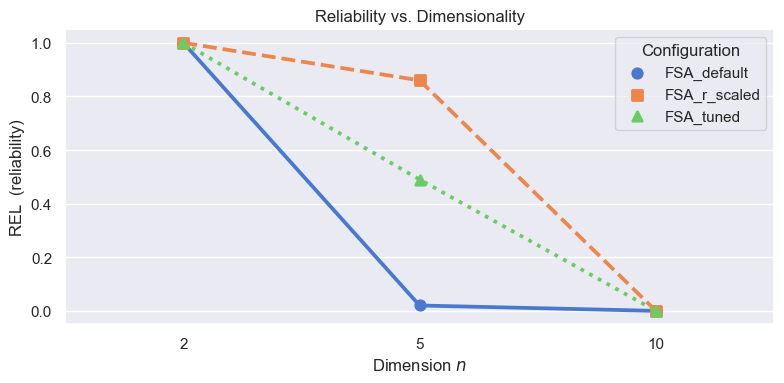

In [7]:
HEUR_ORDER = ['FSA_default', 'FSA_r_scaled', 'FSA_tuned']
PALETTE = sns.color_palette('muted', n_colors=len(HEUR_ORDER))
MARKERS = ['o', 's', '^']
LINES   = ['-', '--', ':']

fig, ax = plt.subplots(figsize=(8, 4))
sns.pointplot(
    data=stats, x='n', y='rel', hue='heur',
    hue_order=HEUR_ORDER, palette=PALETTE,
    markers=MARKERS, linestyles=LINES, ax=ax
)
ax.set_xlabel('Dimension $n$')
ax.set_ylabel('REL  (reliability)')
ax.set_title('Reliability vs. Dimensionality')
ax.legend(title='Configuration')
plt.tight_layout()

#### Mean Number of Evaluations

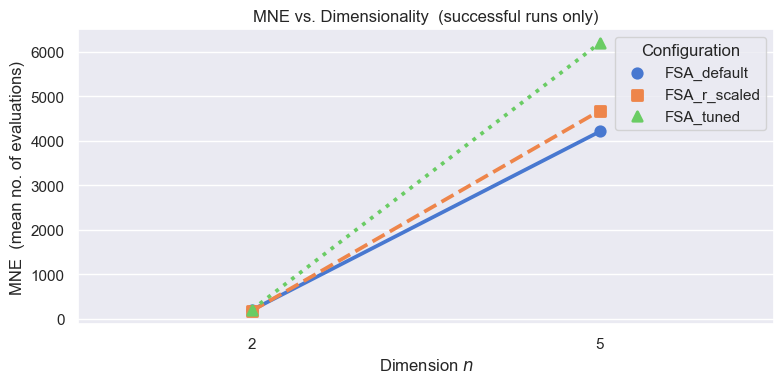

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.pointplot(
    data=stats.dropna(subset=['mne']), x='n', y='mne', hue='heur',
    hue_order=HEUR_ORDER, palette=PALETTE,
    markers=MARKERS, linestyles=LINES, ax=ax
)
ax.set_xlabel('Dimension $n$')
ax.set_ylabel('MNE  (mean no. of evaluations)')
ax.set_title('MNE vs. Dimensionality  (successful runs only)')
ax.legend(title='Configuration')
plt.tight_layout()

#### Feoktistov Criterion

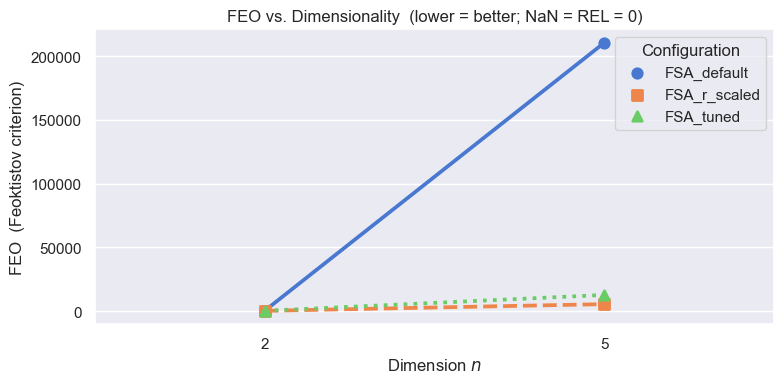

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.pointplot(
    data=stats.dropna(subset=['feo']), x='n', y='feo', hue='heur',
    hue_order=HEUR_ORDER, palette=PALETTE,
    markers=MARKERS, linestyles=LINES, ax=ax
)
ax.set_xlabel('Dimension $n$')
ax.set_ylabel('FEO  (Feoktistov criterion)')
ax.set_title('FEO vs. Dimensionality  (lower = better; NaN = REL = 0)')
ax.legend(title='Configuration')
plt.tight_layout()

#### Summary table

In [10]:
pivot = stats.pivot_table(index='n', columns='heur', values=['rel', 'mne', 'feo'])
pivot.columns = [f'{metric}_{cfg}' for metric, cfg in pivot.columns]
pivot.round(3)

,feo_FSA_default,feo_FSA_r_scaled,feo_FSA_tuned,mne_FSA_default,mne_FSA_r_scaled,mne_FSA_tuned,rel_FSA_default,rel_FSA_r_scaled,rel_FSA_tuned
n,,,,,,,,,
2,190.5,172.690,198.510,190.5,172.690,198.510,1.00,1.00,1.00
5,210575.0,5441.928,12666.847,4211.5,4680.058,6206.755,0.02,0.86,0.49
10,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00


## Conclusion

### Scaling $r$ is the primary lever

* **`FSA_default`** ($r=0.5$ fixed): REL drops sharply with $n$. The L2 step length grows as ${\sim}\,r\sqrt{n}$, so in high dimensions the algorithm consistently overshoots the target region $\|\mathbf{x}\|_2 \leq 0.1$ and cannot refine precisely enough.

* **`FSA_r_scaled`** ($r = 0.5/\sqrt{n}$): scaling the mutation radius recovers reliability across all dimensions. This is the single most important parameter change for high-dimensional continuous optimisation.

### Scaling $n_0$ does not help on unimodal landscapes — and can hurt

* **`FSA_tuned`** ($r = 0.5/\sqrt{n}$, $n_0 = 100n$) is **worse than `FSA_r_scaled`** at intermediate dimensions, despite having the "better" parameter set on paper.

The reason: De Jong 1 is unimodal — there are no local traps to escape. A longer hot phase (large $n_0$) means the algorithm spends more steps doing near-random exploration instead of greedy refinement. For a given budget, `FSA_r_scaled` (small $n_0$, cools fast) has more cold greedy steps available and uses them to converge precisely toward the optimum.

Scaling $n_0 \propto n$ is a useful heuristic on **multimodal** landscapes where the algorithm must escape local minima. On unimodal landscapes it is unnecessary and wastes budget.

### MNE and FEO

MNE rises with $n$ for all configurations — successful runs need more evaluations in higher dimensions, consistent with the linear budget ($\text{maxeval} = 2000n$). FEO separates the three configs cleanly: `FSA_default`'s FEO diverges as REL collapses, while `FSA_r_scaled` maintains the lowest FEO across dimensions.

### Takeaway

| Parameter | Effect on De Jong 1 | Rule |
|---|---|---|
| $r \propto 1/\sqrt{n}$ | critical — prevents step-size blow-up | always apply in high dimensions |
| $n_0 \propto n$ | counterproductive — wastes budget on exploration | apply only on multimodal landscapes |

> For a smooth unimodal bowl, fast cooling + calibrated step size is optimal.  
> The role of $n_0$ scaling becomes clear only when local traps are present.

### Assignment

* Repeat this experiment on the **Rastrigin** function (multimodal, same domain). Does $n_0$ scaling help there? Which additional FSA parameter needs adjustment, and why?